 1. Business Problem Definition
2. Data Understanding
3. Data Validation
4. Exploratory Data Analysis
5. Data Quality Checks
6. External Data Collection
7. Data Integration
8. Feature Engineering
9. Train/Test Strategy
10. Baseline Model
11. Advanced Models
12. Hyperparameter Tuning
13. Model Evaluation
14. Explainability
15. Model Packaging
16. API Deployment
17. Monitoring

1. Business problem: To predict top 3 suitable crops for the input parameters.
2. input:
State
District
Season
Weather Features
Soil Features
3. output
Top 3 suitable Crops
Rice       95%
Maize      82%
Sugarcane  74%
4. Problem type: Multi classification problem.

# Phase 1 : Data Understanding

In [9]:
#install required libraries
%pip install -q numpy pandas seaborn matplotlib scikit-learn kagglehub

Note: you may need to restart the kernel to use updated packages.


In [10]:
# Import Required Libraries
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,StandardScaler 
import pandas as pd
import kagglehub
import os

In [11]:
# Download latest version of the dataset
path = kagglehub.dataset_download("arjunyadav99/indian-agriculture-crop-production-and-yield")

print("Path to dataset files:", path)

print("Files in directory:", os.listdir(path))
file_path = os.path.join(path, "Indian_crop_production_yield_dataset.csv")
df = pd.read_csv(file_path)


Path to dataset files: C:\Users\swaro\.cache\kagglehub\datasets\arjunyadav99\indian-agriculture-crop-production-and-yield\versions\1
Files in directory: ['Indian_crop_production_yield_dataset.csv']


In [12]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 575879 entries, 0 to 575878
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     575879 non-null  str    
 1   District_Name  575879 non-null  str    
 2   Crop_Year      575879 non-null  int64  
 3   Season         575879 non-null  str    
 4   Crop           575879 non-null  str    
 5   Area           575879 non-null  float64
 6   Production     575879 non-null  float64
 7   yield          575879 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 35.1 MB


In [13]:
df.isnull().sum()

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
yield            0
dtype: int64

In [14]:
numerical_columns = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numerical columns:",numerical_columns)
print("categorical columns:",categorical_columns)

Numerical columns: ['Crop_Year', 'Area', 'Production', 'yield']
categorical columns: ['State_Name', 'District_Name', 'Season', 'Crop']


In [15]:
df["State_Name"].value_counts()
df["District_Name"].nunique()
df['Crop'].nunique()

128

In [16]:
# Missing values
df.isnull().sum()

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
yield            0
dtype: int64

####

In [17]:
#duplicate values
duplicates_mask = df.duplicated()
num_duplicates = df[duplicates_mask]

print("Number of duplicates:",num_duplicates)

Number of duplicates: Empty DataFrame
Columns: [State_Name, District_Name, Crop_Year, Season, Crop, Area, Production, yield]
Index: []


Rows ,columns=(575879, 8)
Numerical columns: ['Crop_Year', 'Area', 'Production', 'yield']
categorical columns: ['State_Name', 'District_Name', 'Season', 'Crop']
unique states: 36
unique districts: 730
unique crops:128
Missing values:0
Duplicates :0


# Phase 2 — Data Validation & Quality Assessment

In [18]:
df["State_Name"].value_counts()
df["Season"].value_counts()

Season
Kharif        228520
Rabi          163676
Whole Year    122153
Summer         36071
Winter         13987
Autumn         11472
Name: count, dtype: int64

In [19]:
#Area details checking for outliers & skewness
df["Area"].describe()

#production 
#df["Production"].describe()
#yield = production/Area
# df["yield"].describe()

count    5.758790e+05
mean     1.186614e+04
std      4.407750e+04
min      8.000000e-03
25%      8.200000e+01
50%      5.870000e+02
75%      4.388000e+03
max      8.580100e+06
Name: Area, dtype: float64

In [20]:
df["Crop"].value_counts().head(20)  # dominant crops

Crop
Rice                     36040
Maize                    33757
Moong(Green Gram)        24437
Urad                     23736
Sesamum                  21129
Groundnut                20914
Wheat                    18890
Sugarcane                18467
Rapeseed &Mustard        18226
Arhar/Tur                18103
Onion                    17600
Potato                   17428
Gram                     17369
Jowar                    16603
Dry chillies             15136
Bajra                    13080
Sunflower                12438
Peas & beans (Pulses)    11437
Small millets            11339
Cotton(lint)             10650
Name: count, dtype: int64

In [21]:
# identify the crops with less number
df["Crop"].value_counts().tail(20)  # rare crops

Crop
Cond-spcs other       18
Rajmash Kholar        18
Beet Root             16
Kapas                 12
Peas  (vegetable)     11
Colocosia             11
Ber                   11
other fibres          10
Ricebean (nagadal)    10
Jobster                9
Perilla                9
Turnip                 8
Coffee                 6
Pear                   6
Plums                  6
Litchi                 6
Apple                  4
Peach                  4
Dry Ginger             3
Other Dry Fruit        1
Name: count, dtype: int64

In [22]:
# zero value cheks
print("Area = 0:", (df["Area"] == 0).sum())

print("Production = 0:", (df["Production"] == 0).sum())

print("Yield = 0:", (df["yield"] == 0).sum())

Area = 0: 0
Production = 0: 3634
Yield = 0: 3634


In [23]:
# negative value checks
print("Area < 0:", (df["Area"] < 0).sum())

print("Production < 0:", (df["Production"] < 0).sum())

print("Yield < 0:", (df["yield"] < 0).sum())

Area < 0: 0
Production < 0: 0
Yield < 0: 0


In [24]:
df[df["yield"] == 0].head(20)

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield
395,Andhra Pradesh,ANANTAPUR,2002,Kharif,Soyabean,51.0,0.0,0.0
422,Andhra Pradesh,ANANTAPUR,2002,Whole Year,Cucumber,18.0,0.0,0.0
426,Andhra Pradesh,ANANTAPUR,2002,Whole Year,other fibres,132.0,0.0,0.0
428,Andhra Pradesh,ANANTAPUR,2002,Whole Year,Other Vegetables,1767.0,0.0,0.0
479,Andhra Pradesh,ANANTAPUR,2003,Whole Year,Cucumber,51.0,0.0,0.0
484,Andhra Pradesh,ANANTAPUR,2003,Whole Year,Other Vegetables,1783.0,0.0,0.0
1196,Andhra Pradesh,CHITTOOR,2002,Whole Year,Cabbage,4.0,0.0,0.0
1201,Andhra Pradesh,CHITTOOR,2002,Whole Year,Cucumber,8.0,0.0,0.0
1206,Andhra Pradesh,CHITTOOR,2002,Whole Year,Other Vegetables,918.0,0.0,0.0
1208,Andhra Pradesh,CHITTOOR,2002,Whole Year,Peas (vegetable),1.0,0.0,0.0


1. Found Major class imbalance - RIce vs apple -  need to check after EDA (maintain sample with min rows:100)
2. For production =0 and yield=0 there are data with Area not zero - looks like crop failures. AS there is data for other rows.
3. Outlier detected: in yield, production & Area (right skew)

# Phase 3 : EDA

In [25]:
# Need to check which state has more crops and how crops are diversified:
state_crop_count = (
    df.groupby("State_Name")["Crop"].nunique().sort_values(ascending=False)
)

state_crop_count.head(20)

State_Name
Tamil Nadu           89
Andhra Pradesh       72
Telangana            67
Madhya Pradesh       65
Karnataka            61
Rajasthan            53
Nagaland             51
Manipur              50
Kerala               49
Jammu and Kashmir    46
West Bengal          46
Chhattisgarh         46
Bihar                45
Uttarakhand          43
Uttar Pradesh        43
Odisha               43
Meghalaya            42
Haryana              41
Assam                40
Maharashtra          37
Name: Crop, dtype: int64

In [26]:
# overall top crops 
df["Crop"].value_counts().head(30)

Crop
Rice                     36040
Maize                    33757
Moong(Green Gram)        24437
Urad                     23736
Sesamum                  21129
Groundnut                20914
Wheat                    18890
Sugarcane                18467
Rapeseed &Mustard        18226
Arhar/Tur                18103
Onion                    17600
Potato                   17428
Gram                     17369
Jowar                    16603
Dry chillies             15136
Bajra                    13080
Sunflower                12438
Peas & beans (Pulses)    11437
Small millets            11339
Cotton(lint)             10650
Masoor                   10230
Linseed                   9992
Turmeric                  9943
Barley                    9789
Ragi                      9776
Sweet potato              9767
Other Kharif pulses       9072
Horse-gram                8999
Coriander                 8267
Garlic                    8162
Name: count, dtype: int64

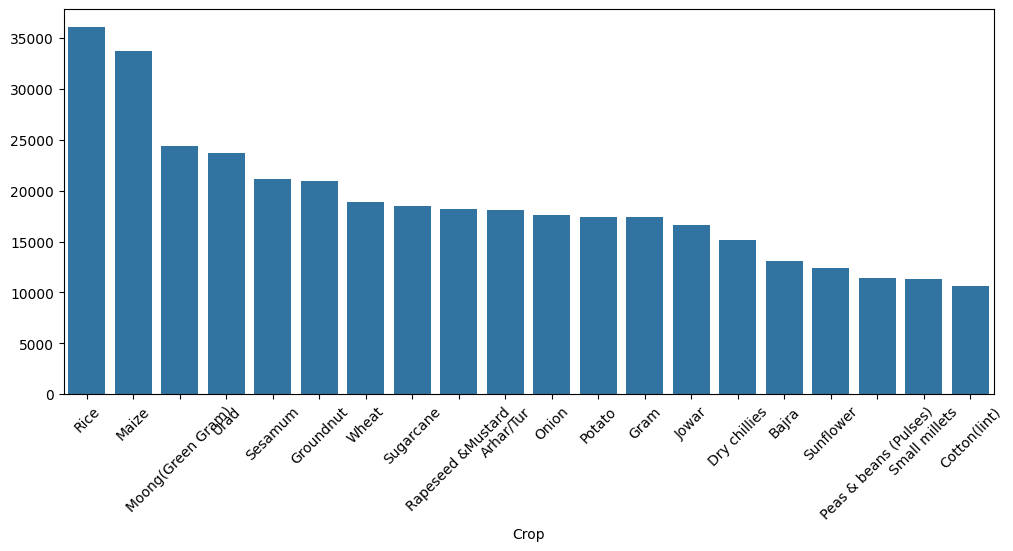

In [27]:
plt.figure(figsize=(12,5))
top_crops = df["Crop"].value_counts().head(20)
sns.barplot(x=top_crops.index,y=top_crops.values)
plt.xticks(rotation=45)
plt.show()

In [28]:
pd.crosstab(
    df["Season"],
    df["Crop"]
)
season_crop = (
    df.groupby(["Season","Crop"])
      .size()
      .reset_index(name="count")
)
season_crop

,Season,Crop,count
0,Autumn,Arecanut,2
1,Autumn,Arhar/Tur,36
2,Autumn,Banana,14
3,Autumn,Black pepper,2
4,Autumn,Cotton(lint),2
...,...,...,...
353,Winter,Sunflower,4
354,Winter,Sweet potato,2
355,Winter,Turmeric,4
356,Winter,Urad,931


In [29]:
df["Crop_Year"].describe()
df["Crop_Year"].value_counts().sort_index()

Crop_Year
1997    17138
1998    22967
1999    24874
2000    26574
2001    26056
2002    30038
2003    31077
2004    27415
2005    26967
2006    27964
2007    28312
2008    28663
2009    28389
2010    28079
2011    29293
2012    27900
2013    29115
2014    25859
2015    16783
2016    17263
2017    17787
2018    18047
2019    19000
2020      319
Name: count, dtype: int64

In [30]:
# outlier of production
df.nlargest(
    20,
    "Production"
)[[
    "State_Name",
    "District_Name",
    "Crop",
    "Area",
    "Production",
    "yield"
]]

,State_Name,District_Name,Crop,Area,Production,yield
352990,Tamil Nadu,COIMBATORE,Coconut,107106.0,1.597800e+11,1.491793e+06
523468,Tamil Nadu,COIMBATORE,Coconut,87749.0,1.488200e+11,1.695974e+06
310207,Tamil Nadu,COIMBATORE,Coconut,104197.0,1.482900e+11,1.423170e+06
516226,Karnataka,TUMAKURU,Coconut,176243.0,1.452725e+11,8.242739e+05
443528,Tamil Nadu,COIMBATORE,Coconut,85448.0,1.401300e+11,1.639945e+06
380031,Karnataka,TUMKUR,Coconut,147539.0,1.393593e+11,9.445591e+05
380030,Karnataka,TUMKUR,Coconut,143110.0,1.351758e+11,9.445587e+05
380029,Karnataka,TUMKUR,Coconut,142248.0,1.347700e+11,9.474298e+05
475166,Karnataka,TUMKUR,Coconut,183232.0,1.305171e+11,7.123052e+05
425544,Karnataka,TUMKUR,Coconut,149419.0,1.283692e+11,8.591223e+05


In [31]:
#outliers for yield
df.nlargest(
    20, "yield"
)[[
    "State_Name","District_Name","Crop","Area","Production","yield"
]]

,State_Name,District_Name,Crop,Area,Production,yield
460330,Assam,TINSUKIA,Coconut,72.0,3.165000e+08,4.395833e+06
318055,West Bengal,BIRBHUM,Coconut,509.0,1.974920e+09,3.880000e+06
353003,Tamil Nadu,ERODE,Coconut,10014.0,3.318000e+10,3.313361e+06
511148,Assam,TINSUKIA,Coconut,71.0,2.340000e+08,3.295775e+06
457172,Andhra Pradesh,PRAKASAM,Coconut,19.0,6.000000e+07,3.157895e+06
412024,Assam,TINSUKIA,Coconut,75.0,2.257000e+08,3.009333e+06
510011,Andhra Pradesh,WEST GODAVARI,Coconut,23316.0,6.941640e+10,2.977200e+06
460328,Assam,TINSUKIA,Coconut,76.0,2.188000e+08,2.878947e+06
280944,Assam,KAMRUP,Coconut,2026.0,5.740500e+09,2.833416e+06
239752,Assam,LAKHIMPUR,Coconut,192.0,5.044000e+08,2.627083e+06


1. crop year distribution is incomplete as yeasr 2020 has less records compared to previous years
2. crop patterns vary geographically, state is important feature.
3. coconut production data is recorded in Number of nuts instead of tones.
4.  Need to normalize the coconut production data  or should not use production/yield for coconut.
5. For crop suitability / recommendation , we do not need the data of production & yield. - helps to learn which crops did well historically


# Phase 3: business Driven EDA

In [32]:
# crops dominate by season.
season_crops = (
    df.groupby(["Season","Crop"]).
    size().
    reset_index(name="Count")
)
season_crops.sort_values(
    ["Season","Crop"],ascending=[True,False]
)

,Season,Crop,Count
27,Autumn,Urad,666
26,Autumn,Turmeric,12
25,Autumn,Tapioca,3
24,Autumn,Sweet potato,3
23,Autumn,Sugarcane,41
...,...,...,...
333,Winter,Dry chillies,12
332,Winter,Cotton(lint),2
331,Winter,Coriander,2
330,Winter,Banana,14


In [33]:
#  Top 10 crops in each state
karnataka = (
    df[df["State_Name"]=="Karnataka"]["Crop"].value_counts().head(20)
)
karnataka

Crop
Maize                  3067
Rice                   2733
Sunflower              2567
Jowar                  2204
Dry chillies           2174
Groundnut              2075
Horse-gram             2073
Onion                  2028
Ragi                   1950
Moong(Green Gram)      1537
Urad                   1310
Potato                 1120
Coconut                1106
Cotton(lint)           1085
Gram                   1051
Arhar/Tur              1034
Sesamum                1010
Cowpea(Lobia)           969
Other Kharif pulses     945
Sugarcane               935
Name: count, dtype: int64

In [34]:
# crops trend over time
crop_trend = (
    df[df["Crop"]=="Rice"].groupby(["Crop_Year"]).size()
)
crop_trend

Crop_Year
1997    1221
1998    1613
1999    1602
2000    1691
2001    1556
2002    1610
2003    1653
2004    1759
2005    1787
2006    1821
2007    1852
2008    1761
2009    1770
2010    1747
2011    1795
2012    1800
2013    1739
2014    1719
2015    1077
2016    1071
2017    1126
2018    1110
2019    1144
2020      16
dtype: int64

In [35]:
crop_counts = df["Crop"].value_counts()
crop_counts
crop_counts.describe()

count      128.000000
mean      4499.054688
std       7272.971483
min          1.000000
25%         39.000000
50%        334.500000
75%       7557.250000
max      36040.000000
Name: count, dtype: float64

In [38]:
crop_counts.quantile(
    [0.25,0.5,0.75,0.9,0.95]
)

0.25       39.00
0.50      334.50
0.75     7557.25
0.90    16832.80
0.95    18741.95
Name: count, dtype: float64

In [39]:
crop_counts = df["Crop"].value_counts()

for thershold in [10,25,50,100,250,500]:
    print(f"Threshold:{thershold}-",(crop_counts>=thershold).sum(),"crops")

Threshold:10- 117 crops
Threshold:25- 103 crops
Threshold:50- 93 crops
Threshold:100- 77 crops
Threshold:250- 68 crops
Threshold:500- 57 crops


In [40]:
print("Total Rows",len(df))

for threshold in [50,100,250,500]:
    
    valid_crops = crop_counts[
        crop_counts >= threshold
    ].index
    
    filtered_df = df[
        df["Crop"].isin(valid_crops)
    ]
    
    print(
        f"Threshold {threshold}:",
        len(filtered_df)
    )

Total Rows 575879
Threshold 50: 575232
Threshold 100: 574009
Threshold 250: 572478
Threshold 500: 568398


Findings
1. Overall unique crop count= 128, median crop count=334 and 25th percentile = 39 - Meaning 128/4=32 crops have count less than 39
2. Other crops like with count 1,2,3,4 are not learnable classes -  cannot rely on them.
3. need to check different thresholds.
4. Rice is stable crop through out the years
5. crop year 2020 is incomplete - so need to drop the year from the crop year.
6. for threshold 100 -  crops 128 to 77 but rows are reduced by 0.32 %
7. for threshold 50 -  still contains 93 crops (weak for training)
8. for threshold 150 - important crops are being removed.


In [41]:
df = df[df["Crop_Year"] < 2020]

In [42]:
crop_counts = df["Crop"].value_counts()

valid_crops = crop_counts[
    crop_counts >= 100
].index

df = df[
    df["Crop"].isin(valid_crops)
]

In [43]:
print(df.shape)

print(df["Crop"].nunique())

(573690, 8)
77


In [44]:
df.to_csv(
    "./Data/crop_production_v1.csv",
    index=False
)

Data Understanding- Analysis

In [45]:
df["Crop"].value_counts().head(20)

Crop
Rice                     36024
Maize                    33740
Moong(Green Gram)        24432
Urad                     23720
Sesamum                  21117
Groundnut                20908
Wheat                    18877
Sugarcane                18462
Rapeseed &Mustard        18213
Arhar/Tur                18093
Onion                    17587
Potato                   17405
Gram                     17358
Jowar                    16603
Dry chillies             15136
Bajra                    13080
Sunflower                12435
Peas & beans (Pulses)    11424
Small millets            11328
Cotton(lint)             10650
Name: count, dtype: int64

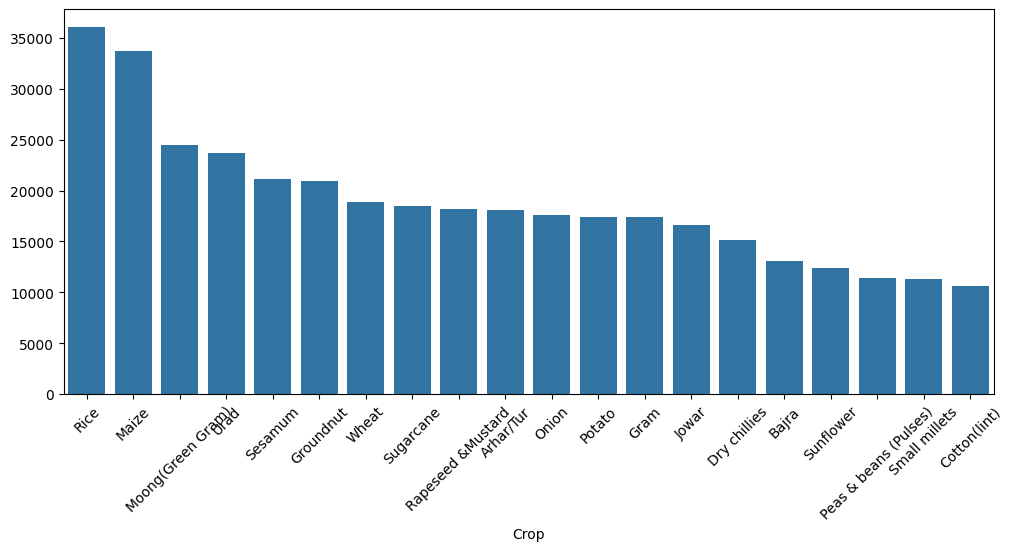

In [46]:
plt.figure(figsize=(12,5))
top_crops = df["Crop"].value_counts().head(20)
sns.barplot(x=top_crops.index,y=top_crops.values)
plt.xticks(rotation=45)
plt.show()

In [47]:
# state wise crop distribution
state_crop_dist = (
    df.groupby(["State_Name"])["Crop"].nunique().sort_values(ascending=False)
)
state_crop_dist.head(20)

State_Name
Tamil Nadu           64
Andhra Pradesh       62
Madhya Pradesh       62
Telangana            59
Karnataka            57
Rajasthan            51
West Bengal          46
Chhattisgarh         45
Bihar                44
Odisha               43
Manipur              43
Uttar Pradesh        43
Kerala               42
Jammu and Kashmir    42
Nagaland             42
Haryana              41
Uttarakhand          41
Meghalaya            41
Assam                38
Himachal Pradesh     36
Name: Crop, dtype: int64

In [48]:
# District wise crop distribution
district_crop_dist = (
    df.groupby(["District_Name"])["Crop"].nunique().sort_values(ascending=False)
)
district_crop_dist.head(20)

District_Name
SALEM              64
DINDIGUL           64
NAMAKKAL           62
DHARMAPURI         62
ERODE              62
COIMBATORE         61
THENI              60
SAGAR              59
VELLORE            59
KHANDWA            59
HOSHANGABAD        59
SHAHDOL            58
REWA               58
BALAGHAT           58
NARSINGHPUR        58
DHAR               58
BANGALORE RURAL    57
JABALPUR           57
TIRUNELVELI        57
EAST GODAVARI      57
Name: Crop, dtype: int64

In [49]:
season_crop = pd.crosstab(
    df["Season"],
    df["Crop"]
)
for season in season_crop.index:
    print(f"Season: {season}")
    print(season_crop.loc[season].sort_values(ascending=False).head(20))

Season: Autumn
Crop
Rice                     4979
Maize                    2351
Ragi                      938
Groundnut                 838
Urad                      666
Sesamum                   611
Moong(Green Gram)         422
Jute                      252
Paddy                     138
Dry chillies               60
Sugarcane                  41
Arhar/Tur                  36
Small millets              32
Banana                     14
Potato                     12
Turmeric                   12
Peas & beans (Pulses)      10
Soyabean                   10
Sannhamp                    9
Jowar                       9
Name: Autumn, dtype: int64
Season: Kharif
Crop
Maize                  17393
Rice                   16665
Arhar/Tur              16218
Sesamum                15065
Urad                   14361
Moong(Green Gram)      13364
Groundnut              12804
Jowar                  11712
Bajra                  11132
Small millets           9968
Cotton(lint)            9351
Other Kharif p

# Phase 4: Data Integration

1. Join keys for Crop production Dataset:
State
District
Year
Season
2. weather dataset columns: 
State|
| District    |
| Year        |
| Temperature |
| Rainfall    |
| Humidity    |
3. soil dataset columns:
State     |
| District  |
| Soil Type |
| N         |
| P         |
| K         |
| pH        |


In [50]:
print(df["Crop_Year"].min())
print(df["Crop_Year"].max())

df.groupby("Crop_Year").size()

1997
2019


Crop_Year
1997    17124
1998    22923
1999    24814
2000    26513
2001    26003
2002    29387
2003    30442
2004    27415
2005    26967
2006    27964
2007    28303
2008    28635
2009    28388
2010    28079
2011    29283
2012    27858
2013    28997
2014    25781
2015    16783
2016    17245
2017    17771
2018    18034
2019    18981
dtype: int64

In [51]:
crop_state = pd.crosstab(
    df["Crop"],
    df["State_Name"]
)

print(crop_state.shape)
print(crop_state.sum(axis=1).describe())
print(crop_state.astype(bool).sum(axis=1).sort_values())

(77, 36)
count       77.000000
mean      7450.519481
std       8130.908801
min        112.000000
25%        483.000000
50%       4623.000000
75%      10650.000000
max      36024.000000
dtype: float64
Crop
Drum Stick            2
Cauliflower           3
Korra                 3
Cardamom              5
Khesari               5
                     ..
Wheat                31
Sugarcane            32
Rapeseed &Mustard    32
Maize                33
Rice                 35
Length: 77, dtype: int64


In [52]:
data_dictionary = {
    "State_Name": "Indian State",
    "District_Name": "Indian District",
    "Crop_Year": "Year of cultivation",
    "Season": "Kharif/Rabi/Summer/etc",
    "Crop": "Target variable",
    "Area": "Cultivated area",
    "Production": "Total production",
    "yield": "Production per unit area"
}

In [53]:
state_year_crop = (
    df.groupby(
        ["State_Name", "Crop_Year"]
    )
    .agg(
        Total_Area=("Area", "sum"),
        Total_Production=("Production", "sum"),
        Crop_Count=("Crop", "nunique")
    )
    .reset_index()
)

state_year_crop.head()

,State_Name,Crop_Year,Total_Area,Total_Production,Crop_Count
0,Andaman and Nicobar Islands,2000,89036.000,8.995152e+09,12
1,Andaman and Nicobar Islands,2001,82326.000,9.061589e+09,9
2,Andaman and Nicobar Islands,2002,90462.800,9.533101e+09,11
3,Andaman and Nicobar Islands,2003,89598.800,9.624942e+09,11
4,Andaman and Nicobar Islands,2004,90617.538,8.805836e+09,11


In [55]:
state_year_crop.to_csv(
    "./Data/state_year_crop_summary.csv",
    index=False
)

In [54]:
# creating state master
states = df["State_Name"].unique().tolist()
states.sort()
states

['Andaman and Nicobar Islands',
 'Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chandigarh',
 'Chhattisgarh',
 'Dadra and Nagar Haveli',
 'Daman and Diu',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jammu and Kashmir',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Laddakh',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'Nagaland',
 'Odisha',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

In [54]:
pd.DataFrame(states, columns=["State_Name"]).to_csv(
    "./Data/state_master.csv",
    index=False
)

In [55]:

newpath = kagglehub.dataset_download("viveksingh2400/indias-state-and-district-wise-weather-data")

print("Path to dataset files:", newpath)

100%|██████████| 11.1k/11.1k [00:00<00:00, 2.38MB/s]

Extracting files...
Path to dataset files: C:\Users\swaro\.cache\kagglehub\datasets\viveksingh2400\indias-state-and-district-wise-weather-data\versions\1


In [59]:

print("Files in directory:", os.listdir(newpath))
file_path1 = os.path.join(newpath, "weather-1.csv")
newdf = pd.read_csv(file_path1)
newdf.tail()

Files in directory: ['weather-1.csv']


,State/UT,District,Temperature (°C),Condition,Humidity (%),Wind Speed (km/h),Last Updated
1147,Delhi,South West Delhi,18.1,Cloudy,40,18.0,2025-01-20 00:00:00
1148,Puducherry,Karaikal,24.9,Light rain shower,81,25.9,2025-01-20 00:00:00
1149,Puducherry,Mahe,26.2,Partly cloudy,74,18.4,2025-01-20 00:00:00
1150,Puducherry,Puducherry,24.8,Sunny,76,26.3,2025-01-20 00:00:00
1151,Puducherry,Yanam,23.6,Sunny,65,15.5,2025-01-20 00:00:00


# Weather and soil data creation with lat and lon

In [57]:
STATE_COORDINATES = {
    "Andaman and Nicobar Islands": (11.7401, 92.6586),
    "Andhra Pradesh": (15.9129, 79.7400),
    "Arunachal Pradesh": (28.2180, 94.7278),
    "Assam": (26.2006, 92.9376),
    "Bihar": (25.0961, 85.3131),
    "Chandigarh": (30.7333, 76.7794),
    "Chhattisgarh": (21.2787, 81.8661),
    "Dadra and Nagar Haveli": (20.1809, 73.0169),
    "Daman and Diu": (20.4283, 72.8397),
    "Delhi": (28.7041, 77.1025),
    "Goa": (15.2993, 74.1240),
    "Gujarat": (22.2587, 71.1924),
    "Haryana": (29.0588, 76.0856),
    "Himachal Pradesh": (31.1048, 77.1734),
    "Jammu and Kashmir": (33.7782, 76.5762),
    "Jharkhand": (23.6102, 85.2799),
    "Karnataka": (15.3173, 75.7139),
    "Kerala": (10.8505, 76.2711),
    "Laddakh": (34.1526, 77.5771),
    "Madhya Pradesh": (22.9734, 78.6569),
    "Maharashtra": (19.7515, 75.7139),
    "Manipur": (24.6637, 93.9063),
    "Meghalaya": (25.4670, 91.3662),
    "Mizoram": (23.1645, 92.9376),
    "Nagaland": (26.1584, 94.5624),
    "Odisha": (20.9517, 85.0985),
    "Puducherry": (11.9416, 79.8083),
    "Punjab": (31.1471, 75.3412),
    "Rajasthan": (27.0238, 74.2179),
    "Sikkim": (27.5330, 88.5122),
    "Tamil Nadu": (11.1271, 78.6569),
    "Telangana": (18.1124, 79.0193),
    "Tripura": (23.9408, 91.9882),
    "Uttar Pradesh": (26.8467, 80.9462),
    "Uttarakhand": (30.0668, 79.0193),
    "West Bengal": (22.9868, 87.8550)
}
import requests

def get_weather_data(lat, lon, year):

    start = f"{year}0101"
    end = f"{year}1231"

    url = (
        "https://power.larc.nasa.gov/api/temporal/daily/point"
        f"?parameters=T2M,RH2M,PRECTOTCORR"
        "&community=AG"
        f"&latitude={lat}"
        f"&longitude={lon}"
        f"&start={start}"
        f"&end={end}"
        "&format=JSON"
    )

    response = requests.get(url)

    return response.json()
def aggregate_weather(data):

    params = data["properties"]["parameter"]

    temperatures = list(params["T2M"].values())

    humidities = list(params["RH2M"].values())

    rainfalls = list(params["PRECTOTCORR"].values())

    return {
        "Avg_Temperature": round(np.mean(temperatures), 2),
        "Avg_Humidity": round(np.mean(humidities), 2),
        "Total_Rainfall": round(np.sum(rainfalls), 2)
    }


In [58]:
results=[]
min_year = df["Crop_Year"].min()
max_year = df["Crop_Year"].max()
for state, (lat, lon) in STATE_COORDINATES.items():
    for year in range(min_year, max_year + 1):
        try:
            weather_data = get_weather_data(lat, lon, year)
            aggregated = aggregate_weather(weather_data)
            results.append({
                "State_Name": state,
                "Crop_Year": year,
                **aggregated
            })
            print(f"Completed {state} - {year}")
        except Exception as e:
            print(f"Error for {state} - {year}: {e}")
            



Completed Andaman and Nicobar Islands - 1997
Completed Andaman and Nicobar Islands - 1998
Completed Andaman and Nicobar Islands - 1999
Completed Andaman and Nicobar Islands - 2000
Completed Andaman and Nicobar Islands - 2001
Completed Andaman and Nicobar Islands - 2002
Completed Andaman and Nicobar Islands - 2003
Completed Andaman and Nicobar Islands - 2004
Completed Andaman and Nicobar Islands - 2005
Completed Andaman and Nicobar Islands - 2006
Completed Andaman and Nicobar Islands - 2007
Completed Andaman and Nicobar Islands - 2008
Completed Andaman and Nicobar Islands - 2009
Completed Andaman and Nicobar Islands - 2010
Completed Andaman and Nicobar Islands - 2011
Completed Andaman and Nicobar Islands - 2012
Completed Andaman and Nicobar Islands - 2013
Completed Andaman and Nicobar Islands - 2014
Completed Andaman and Nicobar Islands - 2015
Completed Andaman and Nicobar Islands - 2016
Completed Andaman and Nicobar Islands - 2017
Completed Andaman and Nicobar Islands - 2018
Completed 

KeyboardInterrupt: 

In [10]:
weather_df = pd.DataFrame(results)

print(weather_df.head())
weather_df.shape

NameError: name 'results' is not defined

In [59]:
# weather_df.to_csv(
#     "weather_state_year.csv",
#     index=False
# )
weather_df = pd.read_csv("./Data/weather_state_year.csv")

In [60]:
weather_df.isnull().sum()

State_Name         0
Crop_Year          0
Avg_Temperature    0
Avg_Humidity       0
Total_Rainfall     0
dtype: int64

In [61]:
weather_df.duplicated(
    subset=["State_Name","Crop_Year"]
).sum()

np.int64(0)

In [62]:
crop_df = df.copy(deep=True)
crop_weather_df = crop_df.merge(
    weather_df,
    on=["State_Name","Crop_Year"],
    how="left"
)

In [63]:
print(crop_weather_df.head())
crop_weather_df.shape

                    State_Name District_Name  Crop_Year      Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000      Kharif   
1  Andaman and Nicobar Islands      NICOBARS       2000      Kharif   
2  Andaman and Nicobar Islands      NICOBARS       2000      Kharif   
3  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year   
4  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year   

                  Crop    Area  Production     yield  Avg_Temperature  \
0             Arecanut  1254.0      2000.0  1.594896            27.57   
1  Other Kharif pulses     2.0         1.0  0.500000            27.57   
2                 Rice   102.0       321.0  3.147059            27.57   
3               Banana   176.0       641.0  3.642045            27.57   
4            Cashewnut   720.0       165.0  0.229167            27.57   

   Avg_Humidity  Total_Rainfall  
0         79.98         2356.32  
1         79.98         2356.32  
2         79.98         2356.32 

(573690, 11)

In [64]:
crop_weather_df[
    [
        "Avg_Temperature",
        "Avg_Humidity",
        "Total_Rainfall"
    ]
].isnull().sum()

Avg_Temperature    0
Avg_Humidity       0
Total_Rainfall     0
dtype: int64

In [8]:
%pip install geopy tqdm

Note: you may need to restart the kernel to use updated packages.


In [9]:
districts = (
    crop_weather_df[["State_Name", "District_Name"]]
    .drop_duplicates()
    .sort_values(["State_Name", "District_Name"])
)

print(districts.shape)
districts.head()
# districts.to_csv(
#     "./Data/district_master.csv",
#     index=False
# )


NameError: name 'crop_weather_df' is not defined

In [78]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from tqdm import tqdm
import pandas as pd
import time

districts = pd.read_csv("./Data/district_master.csv")

geolocator = Nominatim(user_agent="agrisense")
geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1
)

latitudes = []
longitudes = []

for _, row in tqdm(districts.iterrows(),
                   total=len(districts)):

    query = f"{row['District_Name']}, {row['State_Name']}, India"

    try:
        location = geocode(query)

        if location:
            latitudes.append(location.latitude)
            longitudes.append(location.longitude)
        else:
            latitudes.append(None)
            longitudes.append(None)

    except Exception:
        latitudes.append(None)
        longitudes.append(None)

districts["Latitude"] = latitudes
districts["Longitude"] = longitudes


100%|██████████| 796/796 [13:27<00:00,  1.01s/it]


In [ ]:
# districts.to_csv(
#     "./Data/district_coordinates.csv",
#     index=False
# )

In [ ]:
# failed = districts[
#     districts["Latitude"].isna()
# ].copy()
# failed.head()
# failed.shape

(32, 4)

In [ ]:
# district_corrections = {

#     # Telangana districts
#     "ADILABAD": "Adilabad",
#     "KARIMNAGAR": "Karimnagar",
#     "MEDAK": "Medak",
#     "NALGONDA": "Nalgonda",
#     "RANGAREDDI": "Ranga Reddy",
#     "WARANGAL": "Warangal",

#     # Andhra
#     "VISAKHAPATANAM": "Visakhapatnam",

#     # Karnataka
#     "DAKSHIN KANNAD": "Dakshina Kannada",
#     "UTTAR KANNAD": "Uttara Kannada",

#     # Gujarat
#     "DOHAD": "Dahod",
#     "CHHOTAUDEPUR": "Chhota Udaipur",

#     # Punjab
#     "FIROZEPUR": "Ferozepur",

#     # Uttar Pradesh
#     "KUSHI NAGAR": "Kushinagar",

#     # Uttarakhand
#     "UTTAR KASHI": "Uttarkashi",
#     "RUDRA PRAYAG": "Rudraprayag",

#     # West Bengal
#     "24 PARAGANAS NORTH": "North 24 Parganas",
#     "24 PARAGANAS SOUTH": "South 24 Parganas",

#     # Arunachal
#     "LEPARADA": "Lepa Rada",

#     # Assam
#     "SOUTH SALMARA MANCACHAR": "South Salmara-Mankachar",

#     # Himachal
#     "LAHUL AND SPITI": "Lahaul and Spiti",

#     # J&K
#     "LEH LADAKH": "Leh"
# }

# failed["District_Search"] = failed["District_Name"].replace(
#     district_corrections
# )

# failed["District_Search"] = failed["District_Search"].fillna(
#     failed["District_Name"]
# )

In [ ]:
# state_corrections = {

#     "BOKARO": "Jharkhand",
#     "DHANBAD": "Jharkhand",
#     "DUMKA": "Jharkhand",
#     "EAST SINGHBUM": "Jharkhand",
#     "GARHWA": "Jharkhand",
#     "GIRIDIH": "Jharkhand",
#     "GODDA": "Jharkhand",
#     "GUMLA": "Jharkhand",
#     "HAZARIBAGH": "Jharkhand",
#     "LOHARDAGA": "Jharkhand",
#     "PAKUR": "Jharkhand",
#     "PALAMU": "Jharkhand",
#     "WEST SINGHBHUM": "Jharkhand"
# }
# failed["State_Search"] = failed.apply(
#     lambda row:
#         state_corrections.get(
#             row["District_Name"],
#             row["State_Name"]
#         ),
#     axis=1
# )

In [ ]:
# telangana_districts = [
#     "ADILABAD",
#     "KARIMNAGAR",
#     "MEDAK",
#     "NALGONDA",
#     "RANGAREDDI",
#     "WARANGAL"
# ]
# failed.loc[
#     failed["District_Name"].isin(telangana_districts),
#     "State_Search"
# ] = "Telangana"

In [14]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from tqdm import tqdm

geolocator = Nominatim(user_agent="agrisense")

geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1
)

In [90]:
new_lat = []
new_lon = []

for _, row in tqdm(
    failed.iterrows(),
    total=len(failed)
):

    query = (
        f"{row['District_Search']}, "
        f"{row['State_Search']}, India"
    )

    location = geocode(query)

    if location:
        new_lat.append(location.latitude)
        new_lon.append(location.longitude)
    else:
        new_lat.append(None)
        new_lon.append(None)

100%|██████████| 66/66 [01:06<00:00,  1.01s/it]


In [91]:
failed["Latitude"] = new_lat
failed["Longitude"] = new_lon

In [92]:
failed[
    failed["Latitude"].isna()
][[
    "State_Name",
    "District_Name"
]]

,State_Name,District_Name
1,Andaman and Nicobar Islands,NICOBARS
3,Andaman and Nicobar Islands,SOUTH ANDAMANS
99,Bihar,EAST SINGHBUM
174,Delhi,DELHI_TOTAL
214,Haryana,CHARKI DADRI
273,Jharkhand,EAST SINGHBUM
357,Madhya Pradesh,BASTAR
366,Madhya Pradesh,DANTEWADA
369,Madhya Pradesh,DHAMTARI
372,Madhya Pradesh,DURG


In [93]:
districts.set_index(
    ["State_Name","District_Name"],
    inplace=True
)

failed.set_index(
    ["State_Name","District_Name"],
    inplace=True
)

districts.update(
    failed[["Latitude","Longitude"]]
)

districts.reset_index(inplace=True)

In [ ]:
# districts.to_csv(
#     "./Data/district_coordinates_final.csv",
#     index=False
# )

In [ ]:
remaining = districts[
    districts["Latitude"].isna()
][["State_Name","District_Name"]]

print(remaining)
# remaining.to_csv(
#     "./Data/district_coordinates_remaining.csv",
#     index=False
# )

                      State_Name              District_Name
1    Andaman and Nicobar Islands                   NICOBARS
3    Andaman and Nicobar Islands             SOUTH ANDAMANS
99                         Bihar              EAST SINGHBUM
174                        Delhi                DELHI_TOTAL
214                      Haryana               CHARKI DADRI
273                    Jharkhand              EAST SINGHBUM
357               Madhya Pradesh                     BASTAR
366               Madhya Pradesh                  DANTEWADA
369               Madhya Pradesh                   DHAMTARI
372               Madhya Pradesh                       DURG
379               Madhya Pradesh             JANJGIR-CHAMPA
380               Madhya Pradesh                    JASHPUR
382               Madhya Pradesh                  KABIRDHAM
383               Madhya Pradesh                     KANKER
387               Madhya Pradesh                      KORBA
389               Madhya Pradesh        

In [ ]:
# state_fix = {

#     # -----------------------------
#     # Bihar -> Jharkhand
#     # -----------------------------
#     "BOKARO": "Jharkhand",
#     "DHANBAD": "Jharkhand",
#     "DUMKA": "Jharkhand",
#     "EAST SINGHBUM": "Jharkhand",
#     "WEST SINGHBHUM": "Jharkhand",
#     "GARHWA": "Jharkhand",
#     "GIRIDIH": "Jharkhand",
#     "GODDA": "Jharkhand",
#     "GUMLA": "Jharkhand",
#     "HAZARIBAGH": "Jharkhand",
#     "LOHARDAGA": "Jharkhand",
#     "PAKUR": "Jharkhand",
#     "PALAMU": "Jharkhand",

#     # -----------------------------
#     # Madhya Pradesh -> Chhattisgarh
#     # -----------------------------
#     "BASTAR": "Chhattisgarh",
#     "DANTEWADA": "Chhattisgarh",
#     "DHAMTARI": "Chhattisgarh",
#     "DURG": "Chhattisgarh",
#     "JANJGIR-CHAMPA": "Chhattisgarh",
#     "JASHPUR": "Chhattisgarh",
#     "KABIRDHAM": "Chhattisgarh",
#     "KANKER": "Chhattisgarh",
#     "KORBA": "Chhattisgarh",
#     "MAHASAMUND": "Chhattisgarh",
#     "RAJNANDGAON": "Chhattisgarh",
#     "SURGUJA": "Chhattisgarh",

#     # -----------------------------
#     # Uttar Pradesh -> Uttarakhand
#     # -----------------------------
#     "ALMORA": "Uttarakhand",
#     "BAGESHWAR": "Uttarakhand",
#     "CHAMOLI": "Uttarakhand",
#     "CHAMPAWAT": "Uttarakhand",
#     "PITHORAGARH": "Uttarakhand",
#     "RUDRA PRAYAG": "Uttarakhand",
#     "TEHRI GARHWAL": "Uttarakhand",
#     "UDAM SINGH NAGAR": "Uttarakhand",

#     # -----------------------------
#     # Andhra Pradesh -> Telangana
#     # -----------------------------
#     "ADILABAD": "Telangana",
#     "KARIMNAGAR": "Telangana",
#     "MEDAK": "Telangana",
#     "NALGONDA": "Telangana",
#     "RANGAREDDI": "Telangana",
#     "WARANGAL": "Telangana"
# }
# district_fix = {

#     # Karnataka
#     "DAKSHIN KANNAD": "Dakshina Kannada",
#     "UTTAR KANNAD": "Uttara Kannada",

#     # Andhra/Telangana
#     "VISAKHAPATANAM": "Visakhapatnam",
#     "RANGAREDDI": "Ranga Reddy",

#     # Gujarat
#     "DOHAD": "Dahod",
#     "CHHOTAUDEPUR": "Chhota Udaipur",

#     # Haryana
#     "CHARKI DADRI": "Charkhi Dadri",

#     # Punjab
#     "FIROZEPUR": "Ferozepur",
#     "SHAHID BHAGAT SINGH NAGAR": "Shaheed Bhagat Singh Nagar",

#     # Uttarakhand
#     "RUDRA PRAYAG": "Rudraprayag",
#     "UDAM SINGH NAGAR": "Udham Singh Nagar",

#     # Uttar Pradesh
#     "KUSHI NAGAR": "Kushinagar",
#     "SANT KABEER NAGAR": "Sant Kabir Nagar",

#     # West Bengal
#     "24 PARAGANAS NORTH": "North 24 Parganas",
#     "24 PARAGANAS SOUTH": "South 24 Parganas",

#     # Arunachal Pradesh
#     "LEPARADA": "Lepa Rada",

#     # Assam
#     "SOUTH SALMARA MANCACHAR": "South Salmara-Mankachar",

#     # Himachal Pradesh
#     "LAHUL AND SPITI": "Lahaul and Spiti",

#     # Andaman
#     "NICOBARS": "Nicobar Islands",
#     "SOUTH ANDAMANS": "South Andaman",

#     # Delhi
#     "DELHI_TOTAL": "Delhi",

#     # Jammu & Kashmir
#     "LEH LADAKH": "Leh",

#     # Jharkhand
#     "EAST SINGHBUM": "East Singhbhum",
#     "WEST SINGHBHUM": "West Singhbhum",

#     # Chhattisgarh
#     "JANJGIR-CHAMPA": "Janjgir Champa"
# }
# failed["State_Search"] = failed.apply(
#     lambda row: state_fix.get(
#         row["District_Name"],
#         row["State_Name"]
#     ),
#     axis=1
# )

# failed["District_Search"] = failed["District_Name"].replace(
#     district_fix
# )

# failed["District_Search"] = failed["District_Search"].fillna(
#     failed["District_Name"]
# )

In [ ]:
# query = (
#     f"{row['District_Search']}, "
#     f"{row['State_Search']}, India"
# )
# print(
#     failed[
#         ["State_Name",
#          "District_Name",
#          "State_Search",
#          "District_Search"]
#     ]
# )

                      State_Name              District_Name  \
1    Andaman and Nicobar Islands                   NICOBARS   
3    Andaman and Nicobar Islands             SOUTH ANDAMANS   
99                         Bihar              EAST SINGHBUM   
174                        Delhi                DELHI_TOTAL   
214                      Haryana               CHARKI DADRI   
273                    Jharkhand              EAST SINGHBUM   
357               Madhya Pradesh                     BASTAR   
366               Madhya Pradesh                  DANTEWADA   
369               Madhya Pradesh                   DHAMTARI   
372               Madhya Pradesh                       DURG   
379               Madhya Pradesh             JANJGIR-CHAMPA   
380               Madhya Pradesh                    JASHPUR   
382               Madhya Pradesh                  KABIRDHAM   
383               Madhya Pradesh                     KANKER   
387               Madhya Pradesh                      K

In [ ]:
# df[
#     df["District_Name"].isin([
#         "DADRA AND NAGAR HAVELI",
#         "DAMAN",
#         "DIU"
#     ])
# ][["State_Name","District_Name"]].value_counts()

State_Name              District_Name         
Dadra and Nagar Haveli  DADRA AND NAGAR HAVELI    592
Telangana               DADRA AND NAGAR HAVELI     17
Daman and Diu           DIU                         6
                        DAMAN                       6
Telangana               DIU                         1
                        DAMAN                       1
Name: count, dtype: int64

In [ ]:
# special_state_fix = {
#     "DADRA AND NAGAR HAVELI": "Dadra and Nagar Haveli",
#     "DAMAN": "Daman and Diu",
#     "DIU": "Daman and Diu"
# }

In [ ]:
# failed["State_Search"] = failed.apply(
#     lambda row:
#         special_state_fix.get(
#             row["District_Name"],
#             state_fix.get(
#                 row["District_Name"],
#                 row["State_Name"]
#             )
#         ),
#     axis=1
# )

In [ ]:
# new_lat = []
# new_lon = []

# for _, row in tqdm(
#     failed.iterrows(),
#     total=len(failed)
# ):

#     query = (
#         f"{row['District_Search']}, "
#         f"{row['State_Search']}, India"
#     )

#     location = geocode(query)

#     if location:
#         new_lat.append(location.latitude)
#         new_lon.append(location.longitude)
#     else:
#         new_lat.append(None)
#         new_lon.append(None)

100%|██████████| 32/32 [00:32<00:00,  1.03s/it]


In [ ]:
# failed["Latitude"] = new_lat
# failed["Longitude"] = new_lon

In [ ]:
# failed[
#     failed["Latitude"].isna()
# ][[
#     "State_Name",
#     "District_Name"
# ]]

,State_Name,District_Name


In [ ]:
# districts.set_index(
#     ["State_Name","District_Name"],
#     inplace=True
# )

# failed.set_index(
#     ["State_Name","District_Name"],
#     inplace=True
# )

# districts.update(
#     failed[["Latitude","Longitude"]]
# )

# districts.reset_index(inplace=True)

In [ ]:
# districts.to_csv(
#     "./Data/district_coordinates_final1.csv",
#     index=False
# )
# districts[
#     districts["Latitude"].isna()
# ][["State_Name","District_Name"]]

,State_Name,District_Name


In [ ]:
lat = 12.97
lon = 77.59

url = (
    "https://rest.isric.org/soilgrids/v2.0/properties/query"
)

params = {
    "lat": lat,
    "lon": lon,
    "property": [
        "phh2o",
        "nitrogen",
        "soc",
        "clay",
        "sand",
        "silt",
        "cec"
    ]
}

# response = requests.get(
#     url,
#     params=params
# )

print(response.status_code)

200


In [116]:
data = response.json()
data.keys()
import json
json.dumps(data, indent=2)[:3000]

'{\n  "type": "Feature",\n  "geometry": {\n    "type": "Point",\n    "coordinates": [\n      77.59,\n      12.97\n    ]\n  },\n  "properties": {\n    "layers": [\n      {\n        "name": "cec",\n        "unit_measure": {\n          "d_factor": 10,\n          "mapped_units": "mmol(c)/kg",\n          "target_units": "cmol(c)/kg",\n          "uncertainty_unit": ""\n        },\n        "depths": [\n          {\n            "range": {\n              "top_depth": 0,\n              "bottom_depth": 5,\n              "unit_depth": "cm"\n            },\n            "label": "0-5cm",\n            "values": {\n              "Q0.05": 32,\n              "Q0.5": 174,\n              "Q0.95": 516,\n              "mean": 211,\n              "uncertainty": 28\n            }\n          },\n          {\n            "range": {\n              "top_depth": 5,\n              "bottom_depth": 15,\n              "unit_depth": "cm"\n            },\n            "label": "5-15cm",\n            "values": {\n        

In [15]:
def extract_soil_property(data, property_name):

    for layer in data["properties"]["layers"]:

        if layer["name"] == property_name:

            values = []

            for depth in layer["depths"][:3]:

                mean_value = depth["values"].get("mean")

                print(
                    property_name,
                    depth["label"],
                    mean_value
                )

                if mean_value is not None:
                    values.append(mean_value)

            if len(values) == 0:
                return None

            avg_value = sum(values) / len(values)

            d_factor = layer["unit_measure"]["d_factor"]

            return avg_value / d_factor

    return None

In [16]:
def get_soil_features(data):

    return {
        "CEC": extract_soil_property(data, "cec"),
        "Clay": extract_soil_property(data, "clay"),
        "Sand": extract_soil_property(data, "sand"),
        "Silt": extract_soil_property(data, "silt"),
        "pH": extract_soil_property(data, "phh2o"),
        "Nitrogen": extract_soil_property(data, "nitrogen"),
        "OrganicCarbon": extract_soil_property(data, "soc")
    }

In [17]:
URL = "https://rest.isric.org/soilgrids/v2.0/properties/query"

def get_soil_data(lat, lon):

    params = {
        "lat": lat,
        "lon": lon,
        "property": [
            "phh2o",
            "nitrogen",
            "soc",
            "clay",
            "sand",
            "silt",
            "cec"
        ]
    }

    try:

        response = requests.get(
            URL,
            params=params,
            timeout=120
        )

        response.raise_for_status()

        data = response.json()

        return get_soil_features(data)

    except Exception as e:

        print(f"Error: {e}")

        return None

In [ ]:
results = []
district_df = pd.read_csv("./Data/district_coordinates_final.csv")
for idx, row in district_df.iterrows():
    try:
        soil = get_soil_data(
            row["Latitude"],
            row["Longitude"]
        )

        if soil:

            results.append({
                "State_Name": row["State_Name"],
                "District_Name": row["District_Name"],
                **soil
            })

        if idx % 25 == 0:

            pd.DataFrame(results).to_csv(
                "soil_progress.csv",
                index=False
            )

            print(
                f"Saved {idx} districts"
            )
    except Exception as e:

        print(
            f"Error for {row['District_Name']}, "
            f"{row['State_Name']}: {e}"
        )


Error: HTTPSConnectionPool(host='rest.isric.org', port=443): Read timed out. (read timeout=120)
Saved 0 districts
Error: HTTPSConnectionPool(host='rest.isric.org', port=443): Read timed out. (read timeout=120)


In [2]:
%pip install asyncio aiohttp 
import asyncio
import aiohttp
import pandas as pd
import time
import logging
from pathlib import Path

  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)

   ---------------------------------------- 0/9 [propcache]
   ---- ----------------------------------- 1/9 [multidict]
   ---- ----------------------------------- 1/9 [multidict]
   -------- ------------------------------- 2/9 [frozenlist]
   ------------- -------------------------- 3/9 [attrs]
   ------------- -------------------------- 3/9 [attrs]
   ------------- -------------------------- 3/9 [attrs]
   ----------------- ---------------------- 4/9 [asyncio]
   ---------------------- ----------------- 5/9 [aiohappyeyeballs]
   ---------------------- ----------------- 5/9 [aiohappyeyeballs]
   -------------------------- ------------- 6/9 [yarl]
   -------------------------- ------------- 6/9 [yarl]
   ------------------------------- -------- 7/9 [aiosignal]
   ------------------------------- -------- 7/9 [aiosignal]
   ----------------------------------- ---- 8/9 [aioht

In [3]:
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger(__name__)

URL = "https://rest.isric.org/soilgrids/v2.0/properties/query"
PROPERTIES = ["phh2o", "nitrogen", "soc", "clay", "sand", "silt", "cec"]

# Tune these based on API tolerance
MAX_CONCURRENT = 5      # parallel requests at a time
MAX_RETRIES = 4         # retries per district on failure
RETRY_BASE_DELAY = 2.0  # seconds (doubles each retry: 2, 4, 8, 16...)
SAVE_EVERY = 25         # checkpoint frequency
def extract_soil_property(data, property_name):
    for layer in data["properties"]["layers"]:
        if layer["name"] == property_name:
            values = [
                depth["values"]["mean"]
                for depth in layer["depths"][:3]
                if depth["values"].get("mean") is not None
            ]
            if not values:
                return None
            d_factor = layer["unit_measure"]["d_factor"]
            return (sum(values) / len(values)) / d_factor
    return None


def parse_soil_features(data):
    return {
        "CEC":           extract_soil_property(data, "cec"),
        "Clay":          extract_soil_property(data, "clay"),
        "Sand":          extract_soil_property(data, "sand"),
        "Silt":          extract_soil_property(data, "silt"),
        "pH":            extract_soil_property(data, "phh2o"),
        "Nitrogen":      extract_soil_property(data, "nitrogen"),
        "OrganicCarbon": extract_soil_property(data, "soc"),
    }


In [6]:
async def fetch_with_retry(session, semaphore, row, retries=MAX_RETRIES):
    """Fetch soil data for one district with exponential backoff retries."""
    params = {
        "lat": row["Latitude"],
        "lon": row["Longitude"],
        "property": PROPERTIES,
    }
    async with semaphore:
        for attempt in range(retries + 1):
            try:
                async with session.get(URL, params=params, timeout=aiohttp.ClientTimeout(total=120)) as resp:
                    resp.raise_for_status()
                    data = await resp.json()
                    soil = parse_soil_features(data)
                    return {
                        "State_Name":    row["State_Name"],
                        "District_Name": row["District_Name"],
                        **soil,
                    }

            except (aiohttp.ClientError, asyncio.TimeoutError) as e:
                if attempt == retries:
                    log.warning(f"FAILED after {retries} retries: {row['District_Name']}, {row['State_Name']} — {e}")
                    return None
                delay = RETRY_BASE_DELAY * (2 ** attempt)
                log.info(f"Retry {attempt+1}/{retries} for {row['District_Name']} in {delay:.1f}s — {e}")
                await asyncio.sleep(delay)


async def run(district_df, output_path="soil_results.csv", progress_path="soil_progress.csv"):
    results = []
    semaphore = asyncio.Semaphore(MAX_CONCURRENT)

    # Resume from a previous progress file if it exists
    if Path(progress_path).exists():
        done_df = pd.read_csv(progress_path)
        done_keys = set(zip(done_df["State_Name"], done_df["District_Name"]))
        district_df = district_df[
            ~district_df.apply(lambda r: (r["State_Name"], r["District_Name"]) in done_keys, axis=1)
        ]
        results = done_df.to_dict("records")
        log.info(f"Resuming: {len(done_keys)} already done, {len(district_df)} remaining")

    rows = district_df.to_dict("records")
    connector = aiohttp.TCPConnector(limit=MAX_CONCURRENT, ttl_dns_cache=300)

    async with aiohttp.ClientSession(connector=connector) as session:
        tasks = [fetch_with_retry(session, semaphore, row) for row in rows]

        for i, coro in enumerate(asyncio.as_completed(tasks)):
            result = await coro
            if result:
                results.append(result)

            # Periodic checkpoint save
            if (i + 1) % SAVE_EVERY == 0:
                pd.DataFrame(results).to_csv(progress_path, index=False)
                log.info(f"Checkpoint: {i+1}/{len(rows)} processed, {len(results)} succeeded")

    final_df = pd.DataFrame(results)
    final_df.to_csv(output_path, index=False)
    log.info(f"Done. {len(results)} districts saved to {output_path}")
    return final_df

In [4]:
%pip install -q geopandas rasterstats rasterio rioxarray shapely pyogrio tqdm

Note: you may need to restart the kernel to use updated packages.


In [ ]:
district_df = pd.read_csv("./Data/district_coordinates_final.csv")
df = await run(district_df)

In [8]:
import geopandas as gpd
import pandas as pd
from rasterstats import zonal_stats
from tqdm import tqdm

# ---------------------------
# Load District Boundaries
# ---------------------------

districts = gpd.read_file("./Data/gadm41_IND_shp/gadm41_IND_2.shp")

districts = districts.to_crs("EPSG:4326")

# ---------------------------
# Soil Layers
# ---------------------------
PATH = "./Data/Soil/"
soil_layers = {
    "PH": (f"{PATH}phwater.tif", 10),
    "Clay": (f"{PATH}clay.tif", 10),
    "Sand": (f"{PATH}Sand.tif", 10),
    "Silt": (f"{PATH}silt.tif", 10),
    "Nitrogen": (f"{PATH}Nitrogen.tif", 100),
    "SOC": (f"{PATH}soc.tif", 10),
    "CEC": (f"{PATH}CEC.tif", 10)
}

# ---------------------------
# Extract Soil Parameters
# ---------------------------

for column, (raster_path, factor) in tqdm(
        soil_layers.items(),
        desc="Processing Soil Layers"):

    stats = zonal_stats(
        districts,
        raster_path,
        stats=["mean"],
        all_touched=True
    )

    districts[column] = [
        round(s["mean"] / factor, 2)
        if s["mean"] is not None
        else None
        for s in stats
    ]

# ---------------------------
# Final Output
# ---------------------------

soil_df = districts[
    [
        "NAME_1",
        "NAME_2",
        "PH",
        "Clay",
        "Sand",
        "Silt",
        "Nitrogen",
        "SOC",
        "CEC"
    ]
].copy()

soil_df.rename(
    columns={
        "NAME_1": "State_Name",
        "NAME_2": "District_Name"
    },
    inplace=True
)

soil_df.to_csv(
    "india_district_soil_profile.csv",
    index=False
)

print("Completed")
print(soil_df.head())
print(f"Rows: {len(soil_df)}")

Processing Soil Layers: 100%|██████████| 7/7 [01:25<00:00, 12.21s/it]


Completed
            State_Name             District_Name    PH   Clay   Sand   Silt  \
0  Andaman and Nicobar           Nicobar Islands  3.95  22.18  29.48  23.50   
1  Andaman and Nicobar  North and Middle Andaman  4.66  26.81  30.48  24.61   
2  Andaman and Nicobar             South Andaman  4.21  23.06  32.99  23.81   
3       Andhra Pradesh                 Anantapur  6.83  30.11  43.26  23.83   
4       Andhra Pradesh                  Chittoor  6.81  31.88  40.30  26.77   

   Nitrogen    SOC    CEC  
0      3.13  46.24  12.61  
1      3.22  40.87  19.07  
2      3.44  39.20  17.04  
3      1.34  23.75  25.83  
4      1.90  27.89  26.33  
Rows: 676


In [7]:
import rasterio

files = [
   f"{PATH}phwater.tif",
    f"{PATH}clay.tif",
    f"{PATH}Sand.tif",
    f"{PATH}silt.tif",
    f"{PATH}Nitrogen.tif",
    f"{PATH}soc.tif", 
    f"{PATH}CEC.tif"
]

for file in files:
    try:
        with rasterio.open(file) as src:
            src.read(1)
        print(f"OK : {file}")

    except Exception as e:
        print(f"FAILED : {file}")
        print(e)

OK : ./Data/Soil/phwater.tif
OK : ./Data/Soil/clay.tif
OK : ./Data/Soil/Sand.tif
OK : ./Data/Soil/silt.tif
OK : ./Data/Soil/Nitrogen.tif
OK : ./Data/Soil/soc.tif
OK : ./Data/Soil/CEC.tif


In [69]:
crop_districts = set(crop_df["District_Name"].unique())
soil_districts = set(soil_df["District_Name"].unique())

missing = crop_districts - soil_districts
print(len(crop_districts))
print(len(soil_districts))
print(len(crop_districts) - len(soil_districts))
print(sorted(list(missing))[:50])

730
659
71
['24 PARAGANAS NORTH', '24 PARAGANAS SOUTH', 'ADILABAD', 'AGAR MALWA', 'AGRA', 'AHMADABAD', 'AHMEDNAGAR', 'AIZAWL', 'AJMER', 'AKOLA', 'ALAPPUZHA', 'ALIGARH', 'ALIPURDUAR', 'ALIRAJPUR', 'ALLAHABAD', 'ALMORA', 'ALWAR', 'AMBALA', 'AMBEDKAR NAGAR', 'AMETHI', 'AMRAVATI', 'AMRELI', 'AMRITSAR', 'AMROHA', 'ANAND', 'ANANTAPUR', 'ANANTNAG', 'ANJAW', 'ANUGUL', 'ANUPPUR', 'ARARIA', 'ARAVALLI', 'ARIYALUR', 'ARWAL', 'ASHOKNAGAR', 'AURAIYA', 'AURANGABAD', 'AZAMGARH', 'Andaman and Nicobar Islands', 'BADGAM', 'BAGALKOT', 'BAGALKOTE', 'BAGESHWAR', 'BAGHPAT', 'BAHRAICH', 'BAKSA', 'BALAGHAT', 'BALANGIR', 'BALESHWAR', 'BALLARI']


In [77]:
soil_df["District_Name"] = soil_df["District_Name"].str.upper()

In [83]:
def clean_text(x):
    if pd.isna(x):
        return x

    return (
        str(x)
        .strip()
        .upper()
        .replace(".", "")
        .replace(",", "")
    )

In [84]:
for df in [crop_weather_df, soil_df]:

    df["State_Name"] = df["State_Name"].apply(clean_text)

    df["District_Name"] = df["District_Name"].apply(clean_text)

In [97]:
crop_keys = set(
    zip(
        crop_weather_df["State_Name"],
        crop_weather_df["District_Name"]
    )
)

soil_keys = set(
    zip(
        soil_df["State_Name"],
        soil_df["District_Name"]
    )
)

matched = crop_keys.intersection(soil_keys)

print("Crop Districts :", len(crop_keys))
print("Soil Districts :", len(soil_keys))
print("Matched :", len(matched))

Crop Districts : 796
Soil Districts : 666
Matched : 576


In [94]:
crop_keys = set(
    crop_weather_df["merge_key"]
)

soil_keys = set(
    soil_df["merge_key"]
)

matched = crop_keys.intersection(soil_keys)

print("Crop Districts :", len(crop_keys))
print("Soil Districts :", len(soil_keys))
print("Matched :", len(matched))

Crop Districts : 796
Soil Districts : 666
Matched : 577


In [99]:
unmatched = crop_keys - soil_keys

unmatched_df = pd.DataFrame(
    unmatched,
    columns=["State_Name","District_Name"]
)

print(unmatched_df)
unmatched_df.to_csv(
    "unmatched_districts.csv",
    index=False
)

         State_Name  District_Name
0     UTTAR PRADESH  PAURI GARHWAL
1         TELANGANA      BHADRADRI
2      CHHATTISGARH      KABIRDHAM
3     UTTAR PRADESH      BAGESHWAR
4    ANDHRA PRADESH        KHAMMAM
..              ...            ...
215       RAJASTHAN         JALORE
216   DAMAN AND DIU  DAMAN AND DIU
217           BIHAR        GIRIDIH
218       KARNATAKA     VIJAYAPURA
219             GOA            GOA

[220 rows x 2 columns]


In [96]:
print("Crop keys :", len(crop_keys))
print("Soil keys :", len(soil_keys))
print("Matched :", len(crop_keys.intersection(soil_keys)))
print("Unmatched :", len(crop_keys - soil_keys))

Crop keys : 796
Soil keys : 666
Matched : 577
Unmatched : 219


In [89]:
unmatched_df = pd.DataFrame(
    crop_keys - soil_keys,
    columns=["State_Name","District_Name"]
)

print(len(unmatched_df))

print(
    unmatched_df["District_Name"].nunique()
)

220
207


In [90]:
def normalize(x):
    return (
        str(x)
        .upper()
        .strip()
        .replace(".", "")
        .replace(",", "")
        .replace("-", " ")
    )
crop_weather_df["merge_key"] = (
    crop_weather_df["State_Name"].apply(normalize)
    + "|"
    + crop_weather_df["District_Name"].apply(normalize)
)

soil_df["merge_key"] = (
    soil_df["State_Name"].apply(normalize)
    + "|"
    + soil_df["District_Name"].apply(normalize)
)

In [100]:
state_fix = {

    # Telangana districts stored under Andhra Pradesh
    ("ANDHRA PRADESH","ADILABAD"): "TELANGANA",
    ("ANDHRA PRADESH","KHAMMAM"): "TELANGANA",
    ("ANDHRA PRADESH","KARIMNAGAR"): "TELANGANA",
    ("ANDHRA PRADESH","MEDAK"): "TELANGANA",
    ("ANDHRA PRADESH","NALGONDA"): "TELANGANA",
    ("ANDHRA PRADESH","NIZAMABAD"): "TELANGANA",
    ("ANDHRA PRADESH","RANGAREDDI"): "TELANGANA",
    ("ANDHRA PRADESH","WARANGAL"): "TELANGANA",
    ("ANDHRA PRADESH","MAHBUBNAGAR"): "TELANGANA",
    ("ANDHRA PRADESH","HYDERABAD"): "TELANGANA",

    # Jharkhand districts stored under Bihar
    ("BIHAR","BOKARO"): "JHARKHAND",
    ("BIHAR","DHANBAD"): "JHARKHAND",
    ("BIHAR","DUMKA"): "JHARKHAND",
    ("BIHAR","DEOGHAR"): "JHARKHAND",
    ("BIHAR","GARHWA"): "JHARKHAND",
    ("BIHAR","GIRIDIH"): "JHARKHAND",
    ("BIHAR","GODDA"): "JHARKHAND",
    ("BIHAR","GUMLA"): "JHARKHAND",
    ("BIHAR","HAZARIBAGH"): "JHARKHAND",
    ("BIHAR","KODERMA"): "JHARKHAND",
    ("BIHAR","LOHARDAGA"): "JHARKHAND",
    ("BIHAR","PAKUR"): "JHARKHAND",
    ("BIHAR","PALAMU"): "JHARKHAND",
    ("BIHAR","RANCHI"): "JHARKHAND",
    ("BIHAR","SAHEBGANJ"): "JHARKHAND",
    ("BIHAR","CHATRA"): "JHARKHAND",
    ("BIHAR","EAST SINGHBUM"): "JHARKHAND",
    ("BIHAR","WEST SINGHBHUM"): "JHARKHAND",

    # Chhattisgarh districts stored under Madhya Pradesh
    ("MADHYA PRADESH","BASTAR"): "CHHATTISGARH",
    ("MADHYA PRADESH","BILASPUR"): "CHHATTISGARH",
    ("MADHYA PRADESH","DANTEWADA"): "CHHATTISGARH",
    ("MADHYA PRADESH","DHAMTARI"): "CHHATTISGARH",
    ("MADHYA PRADESH","DURG"): "CHHATTISGARH",
    ("MADHYA PRADESH","JANJGIR-CHAMPA"): "CHHATTISGARH",
    ("MADHYA PRADESH","JASHPUR"): "CHHATTISGARH",
    ("MADHYA PRADESH","KABIRDHAM"): "CHHATTISGARH",
    ("MADHYA PRADESH","KANKER"): "CHHATTISGARH",
    ("MADHYA PRADESH","KORBA"): "CHHATTISGARH",
    ("MADHYA PRADESH","KOREA"): "CHHATTISGARH",
    ("MADHYA PRADESH","MAHASAMUND"): "CHHATTISGARGH",
    ("MADHYA PRADESH","RAIPUR"): "CHHATTISGARH",
    ("MADHYA PRADESH","RAJNANDGAON"): "CHHATTISGARH",
    ("MADHYA PRADESH","SURGUJA"): "CHHATTISGARH",

    # Uttarakhand districts stored under UP
    ("UTTAR PRADESH","ALMORA"): "UTTARAKHAND",
    ("UTTAR PRADESH","BAGESHWAR"): "UTTARAKHAND",
    ("UTTAR PRADESH","CHAMOLI"): "UTTARAKHAND",
    ("UTTAR PRADESH","CHAMPAWAT"): "UTTARAKHAND",
    ("UTTAR PRADESH","DEHRADUN"): "UTTARAKHAND",
    ("UTTAR PRADESH","HARIDWAR"): "UTTARAKHAND",
    ("UTTAR PRADESH","NAINITAL"): "UTTARAKHAND",
    ("UTTAR PRADESH","PAURI GARHWAL"): "UTTARAKHAND",
    ("UTTAR PRADESH","PITHORAGARH"): "UTTARAKHAND",
    ("UTTAR PRADESH","RUDRA PRAYAG"): "UTTARAKHAND",
    ("UTTAR PRADESH","TEHRI GARHWAL"): "UTTARAKHAND",
    ("UTTAR PRADESH","UDAM SINGH NAGAR"): "UTTARAKHAND",
    ("UTTAR PRADESH","UTTAR KASHI"): "UTTARAKHAND"
}
district_fix = {

    "DAVANGERE":"DAVANAGERE",
    "BALLARI":"BELLARY",
    "MYSURU":"MYSORE",
    "BELAGAVI":"BELGAUM",
    "TUMAKURU":"TUMKUR",

    "CHIKBALLAPUR":"CHIKKABALLAPURA",
    "CHIKKABALLAPURA":"CHIKBALLAPUR",

    "KALABURAGI":"GULBARGA",
    "VIJAYAPURA":"BIJAPUR",

    "HOOGHLY":"HUGLI",

    "PURBA BARDHAMAN":"BARDHAMAN",
    "PASCHIM BARDHAMAN":"BARDHAMAN",

    "MEDINIPUR EAST":"PURBA MEDINIPUR",
    "MEDINIPUR WEST":"PASCHIM MEDINIPUR",

    "COOCHBEHAR":"COOCH BEHAR",

    "TUTICORIN":"THOOTHUKUDI",

    "PONDICHERRY":"PUDUCHERRY",

    "BEED":"BID",

    "KHERI":"LAKHIMPUR KHERI",

    "KAIMUR (BHABUA)":"KAIMUR"
}
new_districts = [
    "RANIPET",
    "TENKASI",
    "KALLAKURICHI",
    "HANUMAKONDA",
    "KAMAREDDY",
    "NIRMAL",
    "PEDDAPALLI",
    "JANGOAN",
    "SIDDIPET",
    "VIKARABAD",
    "WANAPARTHY",
    "NAGARKURNOOL",
    "YADADRI",
    "JOGULAMBA",
    "JAGITIAL",
    "MAHABUBABAD",
    "NARAYANAPET",
    "MANCHERIAL",
    "MULUGU",
    "MEDCHAL",
    "MEDCHAL MALKAJGIRI",
    "RAJANNA",
    "JAYASHANKAR",
    "KOMARAM BHEEM ASIFABAD",
    "BHADRADRI"
]

In [101]:
for idx,row in crop_weather_df.iterrows():

    key = (row["State_Name"], row["District_Name"])

    if key in state_fix:
        crop_weather_df.at[idx,"State_Name"] = state_fix[key]

crop_weather_df["District_Name"] = (
    crop_weather_df["District_Name"]
    .replace(district_fix)
)

In [102]:
crop_weather_df["State_Name"] = crop_weather_df["State_Name"].str.upper().str.strip()
crop_weather_df["District_Name"] = crop_weather_df["District_Name"].str.upper().str.strip()

soil_df["State_Name"] = soil_df["State_Name"].str.upper().str.strip()
soil_df["District_Name"] = soil_df["District_Name"].str.upper().str.strip()

In [ ]:
merged_df = crop_weather_df.merge(
    soil_df,
    on=["State_Name", "District_Name"],
    how="left"
)


In [116]:
merged_df.to_csv(
    "./Data/crop_weather_soil.csv",
    index=False
)

In [107]:
merged_df.shape

(577685, 20)

In [108]:
missing_soil = merged_df[
    merged_df["PH"].isna()
]

print(missing_soil.shape)

(70100, 20)


In [109]:
missing_soil[
    ["State_Name","District_Name"]
].drop_duplicates()

,State_Name,District_Name
0,ANDAMAN AND NICOBAR ISLANDS,NICOBARS
77,ANDAMAN AND NICOBAR ISLANDS,NORTH AND MIDDLE ANDAMAN
127,ANDAMAN AND NICOBAR ISLANDS,SOUTH ANDAMANS
3139,ANDHRA PRADESH,KADAPA
6146,ANDHRA PRADESH,SPSR NELLORE
...,...,...
526323,TELANGANA,MEDCHAL MALKAJGIRI
527312,TELANGANA,DADRA AND NAGAR HAVELI
527314,TELANGANA,DIU
527326,TELANGANA,DAMAN


In [111]:
unmatched_districts = (
    merged_df[
        merged_df["PH"].isna()
    ][["State_Name","District_Name"]]
    .drop_duplicates()
)

print(len(unmatched_districts))

149


In [112]:
crop_keys = set(
    zip(
        crop_weather_df["State_Name"],
        crop_weather_df["District_Name"]
    )
)

soil_keys = set(
    zip(
        soil_df["State_Name"],
        soil_df["District_Name"]
    )
)

unmatched = crop_keys - soil_keys

unmatched_df = pd.DataFrame(
    unmatched,
    columns=["State_Name","District_Name"]
)

print(unmatched_df.shape)
unmatched_df.head(20)

(149, 2)


,State_Name,District_Name
0,TELANGANA,BHADRADRI
1,CHHATTISGARH,KABIRDHAM
2,WEST BENGAL,COOCH BEHAR
3,UTTARAKHAND,UDAM SINGH NAGAR
4,TELANGANA,HANUMAKONDA
5,MADHYA PRADESH,NARSINGHPUR
6,ASSAM,WEST KARBI ANGLONG
7,KARNATAKA,CHIKBALLAPUR
8,SIKKIM,SOUTH DISTRICT
9,TELANGANA,MEDCHAL MALKAJGIRI


In [113]:
soil_df[["State_Name","District_Name"]].drop_duplicates().shape

(666, 2)

In [114]:
soil_df[
    ["State_Name","District_Name"]
].drop_duplicates().shape

(666, 2)

In [115]:
crop_weather_df[
    ["State_Name","District_Name"]
].drop_duplicates().shape

(732, 2)

In [82]:
soil_df.isnull().sum()

State_Name       0
District_Name    0
PH               0
Clay             0
Sand             0
Silt             0
Nitrogen         0
SOC              0
CEC              0
dtype: int64

In [78]:
final_df = crop_weather_df.merge(
    soil_df,
    on=["State_Name","District_Name"],
    how="left"
)

In [79]:
print(final_df.shape)
print(crop_weather_df.shape)
final_df.head()

(577586, 18)
(573690, 11)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield,Avg_Temperature,Avg_Humidity,Total_Rainfall,PH,Clay,Sand,Silt,Nitrogen,SOC,CEC
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896,27.57,79.98,2356.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000,27.57,79.98,2356.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059,27.57,79.98,2356.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045,27.57,79.98,2356.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167,27.57,79.98,2356.32,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
final_df.isna().sum()

State_Name             0
District_Name          0
Crop_Year              0
Season                 0
Crop                   0
Area                   0
Production             0
yield                  0
Avg_Temperature        0
Avg_Humidity           0
Total_Rainfall         0
PH                 83501
Clay               83501
Sand               83501
Silt               83501
Nitrogen           83501
SOC                83501
CEC                83501
dtype: int64